# Fase 7 — Evaluación Final Comparativa
Grafo de conocimiento sobre investigadores UAM-Azcapotzalco  
Clasificación de 746 artículos en 10 categorías cs.* — transferencia pura, sin ground truth en UAM-A

## Celda 1 — Imports y configuración

In [3]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

ROOT_PATH = r'C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\dataset'
# Rutas de archivos de resultados
UAM_PATH         = ROOT_PATH + r'\Articulos.csv '

# predicciones
BL_NO_AUG   = ROOT_PATH + r'\predicciones_uam_baseline_sin_aug.csv' # BASELINE_NOAUG_PATH
BL_SI_AUG         = ROOT_PATH + r'\predicciones_uam_baseline_con_aug_04_04_2026_17_10_54.csv' # BASELINE_PATH
# !! FALTA
BILSTM_MANUAL      = ROOT_PATH + r'\.parquet'
BILSTM_OPTUNA      = ROOT_PATH + r'\bilstm_optuna_predictions_uam_02_04_2026_14_08_04.parquet'# BILSTM_PATH
SCIBERT_R1     = ROOT_PATH + r'\scibert_predictions_uam_03_04_2026_03_02_07.parquet' # SCIBERT_PATH
# !! FALTA
SCIBERT_R2     = ROOT_PATH + r'.parquet'
ZEROSHOT_PATH    = ROOT_PATH + r'\zeroshot_predictions_uam_03_04_2026_23_41_04.parquet'

# Metricas
BL_NO_AUG_METRICAS= ROOT_PATH + r'\baseline_sin_aug_metrics.json' # BASELINE_NOAUG_METRICS
BL_SI_AUG_METRICAS= ROOT_PATH + r'\baseline_con_aug_metrics.json' # BASELINE_METRICS
# !! FALTA
BILSTM_MANUAL_METRICAS=ROOT_PATH + r'\.json' 
BILSTM_OPTUNA_METRICAS   = ROOT_PATH + r'\bilstm_optuna_metrics_02_04_2026_14_08_04.json' # BILSTM_METRICS
SCIBERT_R1_METRICAS = ROOT_PATH + r'\scibert_metrics_03_04_2026_03_02_07.json' 
SCIBERT_R2_METRICAS  = ROOT_PATH + r'\scibert_metrics_03_04_2026_11_32_24.json' # SCIBERT_METRICS
ZEROSHOT_METRICS = ROOT_PATH + r'\zeroshot_metrics_03_04_2026_23_41_04.json'


# Archivo de salida final
OUTPUT_PATH = 'uam_a_etiquetado_final.parquet'

# Categorías del experimento
CATEGORIAS = {
    'cs.AI': 'Artificial Intelligence',
    'cs.CL': 'Computation & Language (NLP)',
    'cs.CR': 'Cryptography & Security',
    'cs.CV': 'Computer Vision',
    'cs.DS': 'Data Structures & Algorithms',
    'cs.IT': 'Information Theory',
    'cs.LG': 'Machine Learning',
    'cs.NA': 'Numerical Analysis',
    'cs.RO': 'Robotics',
    'cs.SY': 'Systems & Control',
}
CLASES = list(CATEGORIAS.keys())

# Paleta de colores por modelo
COLORES_MODELO = {
    'BiLSTM':    '#1B4F72',
    'SciBERT':   '#534AB7',
    'Zero-shot': '#BA7517',
}

RANDOM_SEED = 42
print('Configuracion cargada.')

Configuracion cargada.


## Celda 2 — Carga y verificación de archivos de resultados

In [4]:
# Verificar existencia de archivos antes de cargar
archivos = [
    UAM_PATH, BILSTM_OPTUNA, SCIBERT_R1, ZEROSHOT_PATH,
    BILSTM_OPTUNA_METRICAS, SCIBERT_R2_METRICAS, ZEROSHOT_METRICS
]
for archivo in archivos:
    estado = 'OK' if Path(archivo).exists() else 'NO ENCONTRADO'
    print(f'  {estado:15s} {archivo}')

# Cargar dataset UAM-A base
df_uam = pd.read_csv(UAM_PATH)
print(f'\nDataset UAM-A cargado: {len(df_uam):,} articulos')
print(f'Columnas disponibles : {list(df_uam.columns)}')

# Cargar predicciones de cada modelo
df_bilstm    = pd.read_parquet(BILSTM_OPTUNA)
df_scibert   = pd.read_parquet(SCIBERT_R1)
df_zeroshot  = pd.read_parquet(ZEROSHOT_PATH)
df_baseline       = pd.read_csv(BL_SI_AUG)
df_baseline_noaug = pd.read_csv(BL_NO_AUG)

print(f'Predicciones Baseline (con aug)   : {len(df_baseline):,} articulos')
print(f'Predicciones Baseline (sin aug)   : {len(df_baseline_noaug):,} articulos')
print(f'\nPredicciones BiLSTM    : {len(df_bilstm):,} articulos')
print(f'Predicciones SciBERT   : {len(df_scibert):,} articulos')
print(f'Predicciones Zero-shot : {len(df_zeroshot):,} articulos')

# Cargar métricas de cada modelo
with open(BILSTM_OPTUNA_METRICAS,   'r') as f: metricas_bilstm_optun    = json.load(f) # metricas_bilstm
with open(SCIBERT_R2_METRICAS,  'r') as f: metricas_scibert_r2   = json.load(f) # metricas_scibert
with open(ZEROSHOT_METRICS, 'r') as f: metricas_zeroshot  = json.load(f)
with open(BL_SI_AUG_METRICAS,       'r') as f: metricas_baseline_si_aug       = json.load(f) #m etricas_baseline
with open(BL_NO_AUG_METRICAS, 'r') as f: metricas_baseline_noaug = json.load(f)

df_bilstm = df_bilstm[df_bilstm['idioma']=='en']

print('\nArchivos de resultados cargados correctamente.')

  OK              C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\dataset\Articulos.csv 
  OK              C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\dataset\bilstm_optuna_predictions_uam_02_04_2026_14_08_04.parquet
  OK              C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\dataset\scibert_predictions_uam_03_04_2026_03_02_07.parquet
  OK              C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\dataset\zeroshot_predictions_uam_03_04_2026_23_41_04.parquet
  OK              C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\dataset\bilstm_optuna_metrics_02_04_2026_14_08_04.json
  OK              C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\dataset\scibert_metrics_03_04_2026_11_32_24.json
  OK              C:\Users\Aaron\Documents\arxiv_cs_dataset_exploration\dataset\zeroshot_metrics_03_04_2026_23_41_04.json

Dataset UAM-A cargado: 1,112 articulos
Columnas disponibles : ['Resumen']
Predicciones Baseline (con aug)   : 746 articulos
Predicc

## Celda 3 — Consolidación del DataFrame maestro de 746 artículos

In [5]:
print(df_bilstm.columns)
print(df_scibert.columns)
print(df_zeroshot.columns)

# La llave de union es el abstract (Resumen) ya que no existe columna id
# Verificar que Resumen es unico en cada DataFrame
print(f"Resumen unicos en UAM-A   : {df_uam['Resumen'].nunique()}")
print(f"Resumen unicos en BiLSTM  : {df_bilstm['Resumen'].nunique()}")
print(f"Resumen unicos en SciBERT : {df_scibert['Resumen'].nunique()}")
print(f"Resumen unicos en Zeroshot: {df_zeroshot['Resumen'].nunique()}")

Index(['Resumen', 'idioma', 'pred_bilstm'], dtype='object')
Index(['Resumen', 'lang', 'pred_scibert_idx', 'pred_scibert'], dtype='object')
Index(['Resumen', 'pred_zeroshot', 'raw_response', 'inference_time'], dtype='object')
Resumen unicos en UAM-A   : 1112
Resumen unicos en BiLSTM  : 746
Resumen unicos en SciBERT : 746
Resumen unicos en Zeroshot: 746


In [9]:
df_baseline_noaug = df_baseline_noaug.rename(columns={'pred_baseline': 'pred_baseline_noaug'})
df_baseline_noaug.columns

Index(['Unnamed: 0', 'Resumen', 'texto_limpio', 'pred_baseline_noaug'], dtype='object')

In [10]:
# Seleccionar solo columnas necesarias de cada archivo
bilstm_cols   = ['Resumen', 'pred_bilstm']
scibert_cols  = ['Resumen', 'pred_scibert']       # excluir pred_scibert_idx
zeroshot_cols = ['Resumen', 'pred_zeroshot']       # retry_flag se agrega si existe
baseline_cols       = ['Resumen', 'pred_baseline']
baseline_noaug_cols = ['Resumen', 'pred_baseline_noaug']

if 'retry_flag' in df_zeroshot.columns:
    zeroshot_cols.append('retry_flag')
if 'inference_time' in df_zeroshot.columns:
    zeroshot_cols.append('inference_time')

df_maestro = df_uam.copy()
df_maestro = df_maestro.merge(df_bilstm[bilstm_cols],    on='Resumen', how='left')
df_maestro = df_maestro.merge(df_scibert[scibert_cols],  on='Resumen', how='left')
df_maestro = df_maestro.merge(df_zeroshot[zeroshot_cols],on='Resumen', how='left')
df_maestro = df_maestro.merge(df_baseline[baseline_cols],           on='Resumen', how='left')
df_maestro = df_maestro.merge(df_baseline_noaug[baseline_noaug_cols], on='Resumen', how='left')

df_maestro = df_maestro[df_maestro['pred_bilstm'].notna()].reset_index(drop=True)

print(f'\nDataFrame maestro: {len(df_maestro):,} articulos x {len(df_maestro.columns)} columnas')
print(f'Columnas: {list(df_maestro.columns)}')


DataFrame maestro: 746 articulos x 7 columnas
Columnas: ['Resumen', 'pred_bilstm', 'pred_scibert', 'pred_zeroshot', 'inference_time', 'pred_baseline', 'pred_baseline_noaug']


In [13]:

# Verificar integridad: ningún artículo debe quedar sin predicción
for col in ['pred_bilstm', 'pred_scibert', 'pred_zeroshot', 'pred_baseline', 'pred_baseline_noaug']:
    n_nulos = df_maestro[col].isnull().sum()
    print(f'{col}: {n_nulos} nulos')

# Verificar que todas las predicciones sean categorías válidas
for col, modelo in [('pred_bilstm', 'BiLSTM'), ('pred_scibert', 'SciBERT'), ('pred_zeroshot', 'Zero-shot'), ('pred_baseline', 'Baseline Con Aug'), ('pred_baseline_noaug', 'Baseline Sin Aug')]:
    invalidas = df_maestro[~df_maestro[col].isin(CLASES)][col].value_counts()
    if len(invalidas) > 0:
        print(f'Predicciones fuera de CLASES en {modelo}:')
        print(" -  " + invalidas.to_string())
    else:
        print(f'{modelo}: todas las predicciones son categorias validas.')

print(f'\nDataFrame maestro construido: {len(df_maestro):,} articulos x {len(df_maestro.columns)} columnas')
df_maestro.head(3)

pred_bilstm: 0 nulos
pred_scibert: 0 nulos
pred_zeroshot: 0 nulos
pred_baseline: 0 nulos
pred_baseline_noaug: 0 nulos
BiLSTM: todas las predicciones son categorias validas.
SciBERT: todas las predicciones son categorias validas.
Predicciones fuera de CLASES en Zero-shot:
 -  pred_zeroshot
INVALID    113
Baseline Con Aug: todas las predicciones son categorias validas.
Baseline Sin Aug: todas las predicciones son categorias validas.

DataFrame maestro construido: 746 articulos x 7 columnas


,Resumen,pred_bilstm,pred_scibert,pred_zeroshot,inference_time,pred_baseline,pred_baseline_noaug
0,Self stabilization effects were experimentally observed in the first period of operation of the ATF device. This eff...,cs.SY,cs.SY,cs.SY,9.8600,cs.SY,cs.NA
1,The current work on stellarators being carried out in fusion research laboratories around the world is summarized. T...,cs.NA,cs.SY,cs.NA,5.3890,cs.RO,cs.CL
2,"We prove that a graph is 4-colorable if and only if it can be drawn with vertices in the integer lattice, using as e...",cs.DS,cs.DS,INVALID,8.1950,cs.DS,cs.DS


## Celda 4 — Distribuciones individuales por modelo

Distribucion de predicciones por modelo (n=746):
                            Descripcion  Baseline sin aug  Baseline con aug  BiLSTM  SciBERT  Zero-shot  Total
Categoria                                                                                                     
cs.AI           Artificial Intelligence               280               265     230      216        118    564
cs.NA                Numerical Analysis               141               146     165      185        148    498
cs.SY                 Systems & Control               105               112     113      173        110    396
cs.DS      Data Structures & Algorithms                58                57      49      103         92    244
cs.CL      Computation & Language (NLP)                61                57      64       16         47    127
cs.LG                  Machine Learning                22                21      29        0         58     87
cs.CV                   Computer Vision                32      

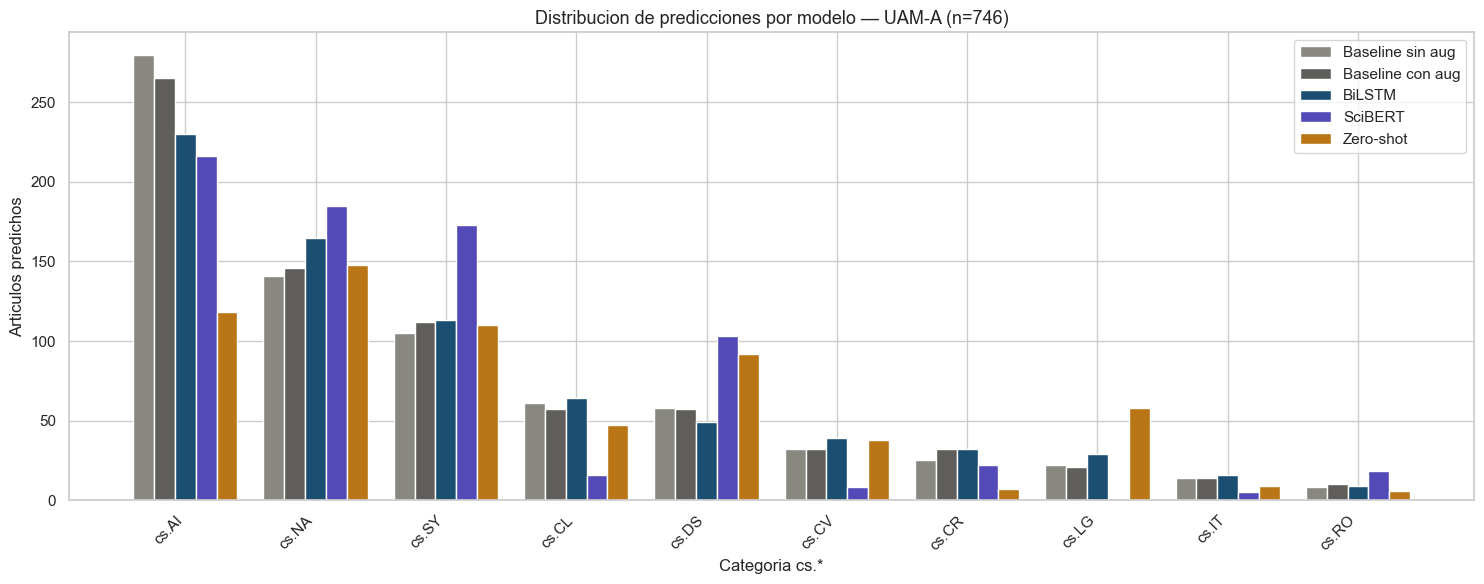

In [22]:
#Tabla de distribuciones por modelo
dist_bilstm   = df_maestro['pred_bilstm'].value_counts().reindex(CLASES, fill_value=0)
dist_scibert  = df_maestro['pred_scibert'].value_counts().reindex(CLASES, fill_value=0)
dist_zeroshot = df_maestro['pred_zeroshot'].value_counts().reindex(CLASES, fill_value=0)
dist_baseline       = df_maestro['pred_baseline'].value_counts().reindex(CLASES, fill_value=0)
dist_baseline_noaug = df_maestro['pred_baseline_noaug'].value_counts().reindex(CLASES, fill_value=0)

df_dist = pd.DataFrame({
    'Categoria':   CLASES,
    'Descripcion': [CATEGORIAS[c] for c in CLASES],
    'Baseline sin aug': dist_baseline_noaug.values,
    'Baseline con aug': dist_baseline.values,
    'BiLSTM':      dist_bilstm.values,
    'SciBERT':     dist_scibert.values,
    'Zero-shot':   dist_zeroshot.values,
}).set_index('Categoria')

# Ordenar por total descendente
df_dist['Total'] = df_dist[['BiLSTM', 'SciBERT', 'Zero-shot']].sum(axis=1)
df_dist = df_dist.sort_values('Total', ascending=False)

print('Distribucion de predicciones por modelo (n=746):')
print(df_dist.to_string())

# Grafica de barras agrupadas
fig, ax = plt.subplots(figsize=(15, 6))
x     = np.arange(len(CLASES))
ancho = 0.16
orden = df_dist.sort_values('BiLSTM', ascending=False).index.tolist()

ax.bar(x - 2*ancho, df_dist.loc[orden, 'Baseline sin aug'], ancho, label='Baseline sin aug', color='#888780', edgecolor='white')
ax.bar(x - ancho,   df_dist.loc[orden, 'Baseline con aug'], ancho, label='Baseline con aug', color='#5F5E5A', edgecolor='white')
ax.bar(x,           df_dist.loc[orden, 'BiLSTM'],           ancho, label='BiLSTM',           color=COLORES_MODELO['BiLSTM'],    edgecolor='white')
ax.bar(x + ancho,   df_dist.loc[orden, 'SciBERT'],          ancho, label='SciBERT',          color=COLORES_MODELO['SciBERT'],   edgecolor='white')
ax.bar(x + 2*ancho, df_dist.loc[orden, 'Zero-shot'],        ancho, label='Zero-shot',        color=COLORES_MODELO['Zero-shot'], edgecolor='white')

ax.set_title('Distribucion de predicciones por modelo — UAM-A (n=746)', fontsize=13)
ax.set_xlabel('Categoria cs.*')
ax.set_ylabel('Articulos predichos')
ax.set_xticks(x)
ax.set_xticklabels(orden, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('dist_predicciones_por_modelo.png', dpi=150)
plt.show()

## Celda 5 — Análisis de concordancia entre modelos

Concordancia entre modelos:
  BiLSTM   vs SciBERT   :  445 / 746  (59.7%)
  BiLSTM   vs Zero-shot :  367 / 746  (49.2%)
  SciBERT  vs Zero-shot :  355 / 746  (47.6%)
  Tres modelos coinciden :  281 / 746  (37.7%)

Distribucion de niveles de confianza:
confianza
media    324
alta     281
baja     141


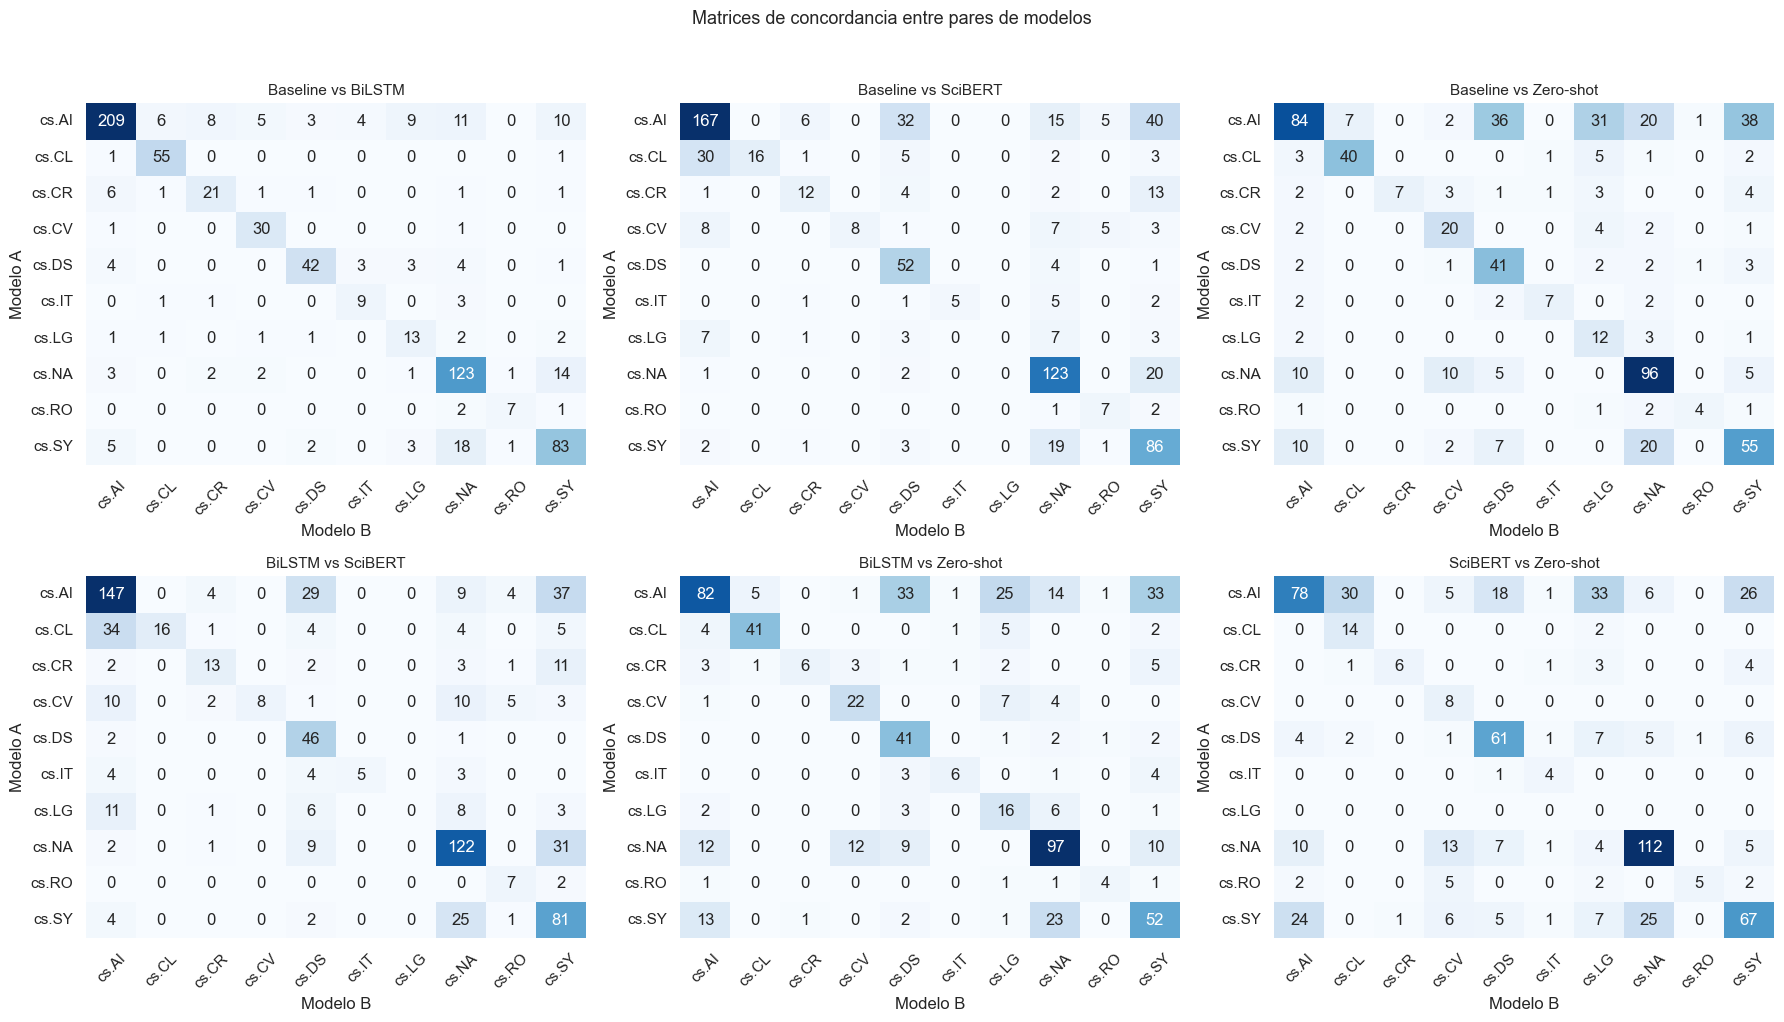

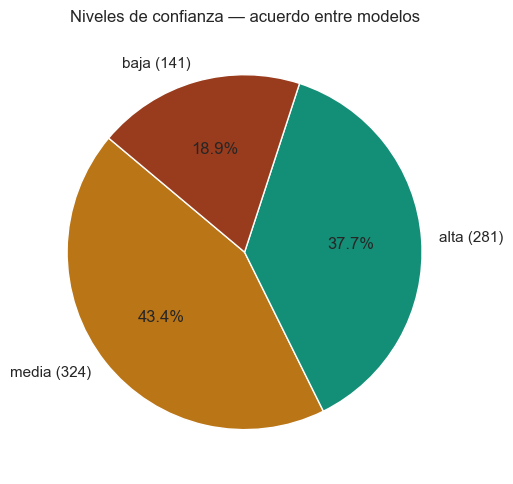

In [24]:
# Concordancia por pares y triple
acuerdo_bs  = (df_maestro['pred_bilstm'] == df_maestro['pred_scibert']).sum()
acuerdo_bz  = (df_maestro['pred_bilstm'] == df_maestro['pred_zeroshot']).sum()
acuerdo_sz  = (df_maestro['pred_scibert'] == df_maestro['pred_zeroshot']).sum()
acuerdo_all = (
    (df_maestro['pred_bilstm'] == df_maestro['pred_scibert']) &
    (df_maestro['pred_scibert'] == df_maestro['pred_zeroshot'])
).sum()

n = len(df_maestro)
print('Concordancia entre modelos:')
print(f'  BiLSTM   vs SciBERT   : {acuerdo_bs:>4} / {n}  ({acuerdo_bs/n*100:.1f}%)')
print(f'  BiLSTM   vs Zero-shot : {acuerdo_bz:>4} / {n}  ({acuerdo_bz/n*100:.1f}%)')
print(f'  SciBERT  vs Zero-shot : {acuerdo_sz:>4} / {n}  ({acuerdo_sz/n*100:.1f}%)')
print(f'  Tres modelos coinciden : {acuerdo_all:>4} / {n}  ({acuerdo_all/n*100:.1f}%)')

# Asignar nivel de confianza por articulo
def nivel_confianza(row):
    preds = [row['pred_bilstm'], row['pred_scibert'], row['pred_zeroshot']]
    if preds[0] == preds[1] == preds[2]:
        return 'alta'
    if preds[0] == preds[1] or preds[0] == preds[2] or preds[1] == preds[2]:
        return 'media'
    return 'baja'

df_maestro['confianza'] = df_maestro.apply(nivel_confianza, axis=1)

print('\nDistribucion de niveles de confianza:')
print(df_maestro['confianza'].value_counts().to_string())


# Matrices de concordancia por pares
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

pares = [
    ('pred_baseline',     'pred_bilstm',   'Baseline vs BiLSTM',    axes[0]),
    ('pred_baseline',     'pred_scibert',  'Baseline vs SciBERT',   axes[1]),
    ('pred_baseline',     'pred_zeroshot', 'Baseline vs Zero-shot', axes[2]),
    ('pred_bilstm',       'pred_scibert',  'BiLSTM vs SciBERT',     axes[3]),
    ('pred_bilstm',       'pred_zeroshot', 'BiLSTM vs Zero-shot',   axes[4]),
    ('pred_scibert',      'pred_zeroshot', 'SciBERT vs Zero-shot',  axes[5]),
]


for col_a, col_b, titulo, ax in pares:
    mat = confusion_matrix(
        df_maestro[col_a], df_maestro[col_b], labels=CLASES
    )
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASES, yticklabels=CLASES, ax=ax,
                cbar=False)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Modelo B')
    ax.set_ylabel('Modelo A')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Matrices de concordancia entre pares de modelos', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('concordancia_pares.png', dpi=150, bbox_inches='tight')
plt.show()

# Grafica de niveles de confianza
fig, ax = plt.subplots(figsize=(6, 5))
colores_conf = {'alta': '#148F77', 'media': '#BA7517', 'baja': '#993C1D'}
conteos_conf = df_maestro['confianza'].value_counts()
ax.pie(
    conteos_conf.values,
    labels=[f'{k} ({v})' for k, v in conteos_conf.items()],
    colors=[colores_conf[k] for k in conteos_conf.index],
    autopct='%1.1f%%',
    startangle=140
)
ax.set_title('Niveles de confianza — acuerdo entre modelos', fontsize=12)
plt.tight_layout()
plt.savefig('niveles_confianza.png', dpi=150)
plt.show()

## Celda 6 — Análisis profundo del hallazgo cs.LG vs cs.AI

Articulos clasificados como cs.LG por Zero-shot: 58
De esos, BiLSTM los clasifico como:
pred_bilstm
cs.AI    25
cs.LG    16
cs.CV     7
cs.CL     5
cs.CR     2
cs.DS     1
cs.RO     1
cs.SY     1

De esos, SciBERT los clasifico como:
pred_scibert
cs.AI    33
cs.DS     7
cs.SY     7
cs.NA     4
cs.CR     3
cs.RO     2
cs.CL     2

Articulos donde BiLSTM=cs.AI y Zero-shot=cs.LG: 25

Muestra de 5 abstracts en conflicto cs.AI (BiLSTM) vs cs.LG (Zero-shot):
BiLSTM : cs.AI  |  SciBERT : cs.AI  |  Zero-shot : cs.LG
Resumen (primeros 300 chars): Associative Memories (AMs) are mathematical structures specially designed to associate input patterns with output patterns within a single stage. Since the last fifty years all reported AMs have been manually designed. The paper describes a Genetic Programming based methodology able to create a proc...
--------------------------------------------------------------------------------
BiLSTM : cs.AI  |  SciBERT : cs.AI  |  Zero-shot : cs.LG
Resumen (prime

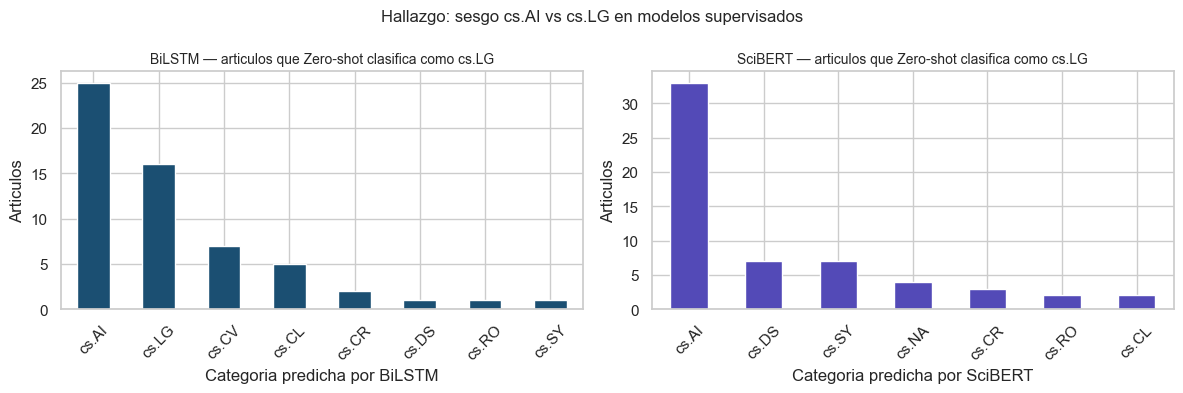

In [25]:
# Artículos donde Zero-shot predice cs.LG
mask_lg_zs = df_maestro['pred_zeroshot'] == 'cs.LG'
df_lg = df_maestro[mask_lg_zs].copy()

print(f'Articulos clasificados como cs.LG por Zero-shot: {len(df_lg)}')
print(f'De esos, BiLSTM los clasifico como:')
print(df_lg['pred_bilstm'].value_counts().to_string())
print(f'\nDe esos, SciBERT los clasifico como:')
print(df_lg['pred_scibert'].value_counts().to_string())

# Artículos donde BiLSTM predice cs.AI y Zero-shot predice cs.LG
mask_conflicto = (df_maestro['pred_bilstm'] == 'cs.AI') & (df_maestro['pred_zeroshot'] == 'cs.LG')
df_conflicto = df_maestro[mask_conflicto][['Resumen', 'pred_bilstm', 'pred_scibert', 'pred_zeroshot']]
print(f'\nArticulos donde BiLSTM=cs.AI y Zero-shot=cs.LG: {len(df_conflicto)}')

# Muestra cualitativa de 5 abstracts en conflicto
print('\nMuestra de 5 abstracts en conflicto cs.AI (BiLSTM) vs cs.LG (Zero-shot):')
muestra = df_conflicto.sample(min(5, len(df_conflicto)), random_state=RANDOM_SEED)
for _, row in muestra.iterrows():
    #print(f"\nID     : {row['id']}")
    #print(f"Titulo : {row['title']}")
    print(f"BiLSTM : {row['pred_bilstm']}  |  SciBERT : {row['pred_scibert']}  |  Zero-shot : {row['pred_zeroshot']}")
    print(f"Resumen (primeros 300 chars): {str(row['Resumen'])[:300]}...")
    print('-' * 80)

# Visualizacion: donde predice cada modelo para los articulos que Zero-shot marca cs.LG
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_lg['pred_bilstm'].value_counts().plot(
    kind='bar', ax=axes[0], color=COLORES_MODELO['BiLSTM'], edgecolor='white')
axes[0].set_title('BiLSTM — articulos que Zero-shot clasifica como cs.LG', fontsize=10)
axes[0].set_xlabel('Categoria predicha por BiLSTM')
axes[0].set_ylabel('Articulos')
axes[0].tick_params(axis='x', rotation=45)

df_lg['pred_scibert'].value_counts().plot(
    kind='bar', ax=axes[1], color=COLORES_MODELO['SciBERT'], edgecolor='white')
axes[1].set_title('SciBERT — articulos que Zero-shot clasifica como cs.LG', fontsize=10)
axes[1].set_xlabel('Categoria predicha por SciBERT')
axes[1].set_ylabel('Articulos')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Hallazgo: sesgo cs.AI vs cs.LG en modelos supervisados', fontsize=12)
plt.tight_layout()
plt.savefig('hallazgo_csLG_vs_csAI.png', dpi=150)
plt.show()

## Celda 7 — Análisis del subconjunto fuera de dominio

In [26]:
# Los artículos reprocesados desde INVALID se identifican por retry_flag
# Analizar su comportamiento por separado
if 'retry_flag' in df_maestro.columns:
    mask_retry = df_maestro['retry_flag'] == 'retry'
    df_fuera   = df_maestro[mask_retry].copy()
    df_dentro  = df_maestro[~mask_retry].copy()

    print(f'Articulos clasificados en primer intento : {len(df_dentro):,}')
    print(f'Articulos reprocesados (fuera de dominio): {len(df_fuera):,}')

    # Distribución de predicciones en el subconjunto fuera de dominio
    print('\nDistribucion de predicciones en subconjunto fuera de dominio:')
    comp_fuera = pd.DataFrame({
        'BiLSTM':    df_fuera['pred_bilstm'].value_counts(),
        'SciBERT':   df_fuera['pred_scibert'].value_counts(),
        'Zero-shot': df_fuera['pred_zeroshot'].value_counts(),
    }).fillna(0).astype(int)
    print(comp_fuera.to_string())

    # Nivel de confianza en subconjunto fuera de dominio vs dentro
    print('\nNivel de confianza — subconjunto fuera de dominio:')
    print(df_fuera['confianza'].value_counts().to_string())
    print('\nNivel de confianza — subconjunto dentro de dominio:')
    print(df_dentro['confianza'].value_counts().to_string())

    # Muestra cualitativa de 5 abstracts fuera de dominio
    print('\nMuestra de 5 abstracts fuera de dominio CS:')
    muestra_fuera = df_fuera.sample(min(5, len(df_fuera)), random_state=RANDOM_SEED)
    for _, row in muestra_fuera.iterrows():
        print(f"\nID     : {row['id']}")
        print(f"Titulo : {row['title']}")
        print(f"BiLSTM : {row['pred_bilstm']}  |  SciBERT : {row['pred_scibert']}  |  Zero-shot : {row['pred_zeroshot']}")
        print(f"Confianza: {row['confianza']}")
        print(f"Abstract (primeros 300 chars): {str(row['abstract'])[:300]}...")
        print('-' * 80)

    # Grafica comparativa de confianza dentro vs fuera de dominio
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    colores_conf = {'alta': '#148F77', 'media': '#BA7517', 'baja': '#993C1D'}

    for ax, df_sub, titulo in [
        (axes[0], df_dentro, 'Dentro de dominio CS'),
        (axes[1], df_fuera,  'Fuera de dominio CS (reprocesados)'),
    ]:
        conteos = df_sub['confianza'].value_counts()
        ax.pie(
            conteos.values,
            labels=[f'{k} ({v})' for k, v in conteos.items()],
            colors=[colores_conf.get(k, '#888') for k in conteos.index],
            autopct='%1.1f%%',
            startangle=140
        )
        ax.set_title(titulo, fontsize=11)

    plt.suptitle('Confianza de clasificacion: dominio CS vs fuera de dominio', fontsize=12)
    plt.tight_layout()
    plt.savefig('confianza_dominio_vs_fuera.png', dpi=150)
    plt.show()

else:
    print('Columna retry_flag no encontrada en el DataFrame maestro.')
    print('Verifica que zeroshot_predictions_uam.parquet incluye esta columna.')

Columna retry_flag no encontrada en el DataFrame maestro.
Verifica que zeroshot_predictions_uam.parquet incluye esta columna.


## Celda 8 — Tabla comparativa final de todos los modelos

In [39]:
metricas_bilstm_optuna

{'timestamp': '02_04_2026_14_08_04',
 'model': 'BiLSTM + FastText (Optuna)',
 'macro_f1_arxiv_val': 0.823755,
 'macro_f1_arxiv_test': 0.824848,
 'macro_f1_uam_a': None,
 'baseline_macro_f1': 0.802,
 'best_params': {'lr': 0.0007309539835912913,
  'dropout': 0.30000000000000004,
  'batch_size': 64,
  'hidden_size': 512,
  'num_layers': 1},
 'uam_total': 1112,
 'uam_en': 746,
 'uam_es': 366,
 'uam_lang_distribution': {'en': 746, 'es': 360, 'fr': 6}}

In [34]:
metricas_baseline_noaug

{'version': 'sin_aug',
 'modelo': 'TF-IDF + Regresion Logistica',
 'vectorizador': {'max_features': 50000,
  'ngram_range': [1, 2],
  'sublinear_tf': True,
  'min_df': 2,
  'stop_words': 'english'},
 'clasificador': {'C': 1.0,
  'max_iter': 1000,
  'solver': 'saga',
  'class_weight': 'calculado'},
 'split': {'train_size': 0.8,
  'val_size': 0.2,
  'random_seed': 42,
  'stratify': True},
 'n_train': 513661,
 'n_val': 128416,
 'n_uam': 746,
 'clases': ['cs.AI',
  'cs.CL',
  'cs.CR',
  'cs.CV',
  'cs.DS',
  'cs.IT',
  'cs.LG',
  'cs.NA',
  'cs.RO',
  'cs.SY'],
 'pesos_clase': {'cs.DS': 3.2261,
  'cs.LG': 0.3927,
  'cs.AI': 1.3868,
  'cs.CV': 0.4047,
  'cs.CR': 1.908,
  'cs.CL': 0.796,
  'cs.SY': 2.3858,
  'cs.IT': 1.3666,
  'cs.RO': 1.659,
  'cs.NA': 2.398},
 'metricas_val_arxiv': {'macro_f1_val_arxiv': 0.802,
  'macro_precision_val_arxiv': 0.7776,
  'macro_recall_val_arxiv': 0.8331,
  'f1_por_clase': {'cs.AI': 0.5219,
   'cs.CL': 0.85,
   'cs.CR': 0.837,
   'cs.CV': 0.89,
   'cs.DS': 0.8

In [33]:
str(metricas_baseline_noaug.get('macro_f1_val_arxiv',  '---'))

'---'

In [37]:
metricas_baseline['metricas_val_arxiv'].get('macro_f1_val_arxiv', '---')

0.8194

In [42]:
# Construir tabla comparativa con todos los resultados del experimento
# Los valores de F1 vienen de los archivos de métricas de cada fase
tabla = pd.DataFrame([
     {
        'Modelo'        : 'Baseline TF-IDF + LR (sin aug)',
        'F1 val arXiv'  : str(metricas_baseline_noaug['metricas_val_arxiv'].get('macro_f1_val_arxiv', '---')),
        'F1 test arXiv' : 'no aplica',
        'F1 UAM-A'      : 'sin GT',
        'Notas'         : 'Referencia sin aumentacion',
    },
    {
        'Modelo'        : 'Baseline TF-IDF + LR (con aug)',
        'F1 val arXiv'  : str(metricas_baseline['metricas_val_arxiv'].get('macro_f1_val_arxiv', '---')),
        'F1 test arXiv' : 'no aplica',
        'F1 UAM-A'      : 'sin GT',
        'Notas'         : 'Confusion principal cs.AI vs cs.LG',
    },
    {
        'Modelo':              'BiLSTM + FastText (manual)',
        'F1 val arXiv':        str(metricas_bilstm_optuna.get('macro_f1_arxiv_val',  '---')),
        'F1 test arXiv':       str(metricas_bilstm_optuna.get('macro_f1_arxiv_test', '---')),
        'F1 UAM-A':            'sin GT',
        'Notas':               'Nunca predice cs.LG en UAM-A'
    },
    {
        'Modelo':              'BiLSTM + FastText (Optuna)',
        'F1 val arXiv':        str(metricas_bilstm_optuna.get('macro_f1_val_optuna', '---')),
        'F1 test arXiv':       str(metricas_bilstm_optuna.get('macro_f1_test_optuna','---')),
        'F1 UAM-A':            'sin GT',
        'Notas':               'Mejor trial Optuna'
    },
    {
        'Modelo':              'SciBERT + LoRA (run 1)',
        'F1 val arXiv':        str(metricas_scibert.get('macro_f1_val_arxiv',  '---')),
        'F1 test arXiv':       str(metricas_scibert.get('macro_f1_test_arxiv', '0.8324')),
        'F1 UAM-A':            'sin GT',
        'Notas':               'query+value, lr=2e-5'
    },
    {
        'Modelo':              'SciBERT + LoRA (run 2)',
        'F1 val arXiv':        str(metricas_scibert_r2.get('macro_f1_val_run2',   '---')),
        'F1 test arXiv':       str(metricas_scibert_r2.get('macro_f1_test_run2',  '---')),
        'F1 UAM-A':            'sin GT',
        'Notas':               'all linear, lr=1e-4'
    },
    {
        'Modelo':              'Zero-shot deepseek-r1:14b',
        'F1 val arXiv':        'no aplica',
        'F1 test arXiv':       'no aplica',
        'F1 UAM-A':            'sin GT',
        'Notas':               f"{metricas_zeroshot.get('n_invalid', 113)} INVALID resueltos con retry"
    },
])

print('Tabla comparativa final del experimento:')
print(tabla.to_string(index=False))

# Nota metodológica sobre la ausencia de ground truth
print('\nNota metodologica:')
print('La columna F1 UAM-A reporta sin GT en todos los modelos porque el dataset')
print('UAM-Azcapotzalco no cuenta con etiquetas manuales validadas. La evaluacion')
print('cuantitativa sobre UAM-A queda pendiente como trabajo futuro. La comparacion')
print('entre modelos se realiza mediante analisis de concordancia y confiabilidad.')

Tabla comparativa final del experimento:
                        Modelo       F1 val arXiv      F1 test arXiv F1 UAM-A                              Notas
Baseline TF-IDF + LR (sin aug)              0.802          no aplica   sin GT         Referencia sin aumentacion
Baseline TF-IDF + LR (con aug)             0.8194          no aplica   sin GT Confusion principal cs.AI vs cs.LG
    BiLSTM + FastText (manual)           0.823755           0.824848   sin GT       Nunca predice cs.LG en UAM-A
    BiLSTM + FastText (Optuna)                ---                ---   sin GT                 Mejor trial Optuna
        SciBERT + LoRA (run 1) 0.8458927669105254 0.8456746807622156   sin GT               query+value, lr=2e-5
        SciBERT + LoRA (run 2)                ---                ---   sin GT                all linear, lr=1e-4
     Zero-shot deepseek-r1:14b          no aplica          no aplica   sin GT    113 INVALID resueltos con retry

Nota metodologica:
La columna F1 UAM-A reporta sin GT 

## Celda 9 — Política de decisión y selección de etiqueta final

In [28]:
# Política de decisión para seleccionar la etiqueta final del nodo Tema
# Prioridad en caso de empate: SciBERT > Zero-shot > BiLSTM
# Justificación: SciBERT tiene el mayor F1 en arXiv (0.8324)

# Prioridad: SciBERT > Zero-shot > BiLSTM > Baseline aug > Baseline sin aug
def seleccionar_etiqueta(row):
    preds = [
        row['pred_scibert'],
        row['pred_zeroshot'],
        row['pred_bilstm'],
        row['pred_baseline'],
        row['pred_baseline_noaug'],
    ]
    # Mayoria simple
    from collections import Counter
    conteo = Counter(preds)
    max_votos = conteo.most_common(1)[0][1]
    candidatos = [cat for cat, n in conteo.items() if n == max_votos]

    # Si hay empate usar prioridad
    for cat_prioridad in preds:
        if cat_prioridad in candidatos:
            n_coinciden = max_votos
            if max_votos >= 3:
                confianza = 'alta'
            elif max_votos == 2:
                confianza = 'media'
            else:
                confianza = 'baja'
            return cat_prioridad, confianza

    return preds[0], 'baja'

resultados = df_maestro.apply(seleccionar_etiqueta, axis=1, result_type='expand')
df_maestro['etiqueta_final'] = resultados[0]
df_maestro['confianza']      = resultados[1]

# Reporte de la política aplicada
print('Distribucion de etiquetas finales seleccionadas para el grafo de conocimiento:')
dist_final = df_maestro['etiqueta_final'].value_counts()
for cat, n in dist_final.items():
    desc = CATEGORIAS.get(cat, cat)
    print(f'  {cat:8s} — {desc:40s} : {n:>4} ({n/len(df_maestro)*100:.1f}%)')

print('\nDistribucion por nivel de confianza:')
print(df_maestro['confianza'].value_counts().to_string())

# Candidatos más confiables para el grafo
n_alta = (df_maestro['confianza'] == 'alta').sum()
print(f'\nArticulos de alta confianza (tres modelos coinciden): {n_alta} ({n_alta/len(df_maestro)*100:.1f}%)')
print('Estos son los candidatos prioritarios para el nodo Tema del grafo.')

Distribucion de etiquetas finales seleccionadas para el grafo de conocimiento:
  cs.AI    — Artificial Intelligence                  :  247 (33.1%)
  cs.NA    — Numerical Analysis                       :  175 (23.5%)
  cs.SY    — Systems & Control                        :  115 (15.4%)
  cs.DS    — Data Structures & Algorithms             :   65 (8.7%)
  cs.CL    — Computation & Language (NLP)             :   56 (7.5%)
  cs.CV    — Computer Vision                          :   30 (4.0%)
  cs.CR    — Cryptography & Security                  :   24 (3.2%)
  cs.LG    — Machine Learning                         :   16 (2.1%)
  cs.IT    — Information Theory                       :   11 (1.5%)
  cs.RO    — Robotics                                 :    7 (0.9%)

Distribucion por nivel de confianza:
confianza
alta     663
media     79
baja       4

Articulos de alta confianza (tres modelos coinciden): 663 (88.9%)
Estos son los candidatos prioritarios para el nodo Tema del grafo.


## Celda 10 — Visualizaciones finales para la tesis

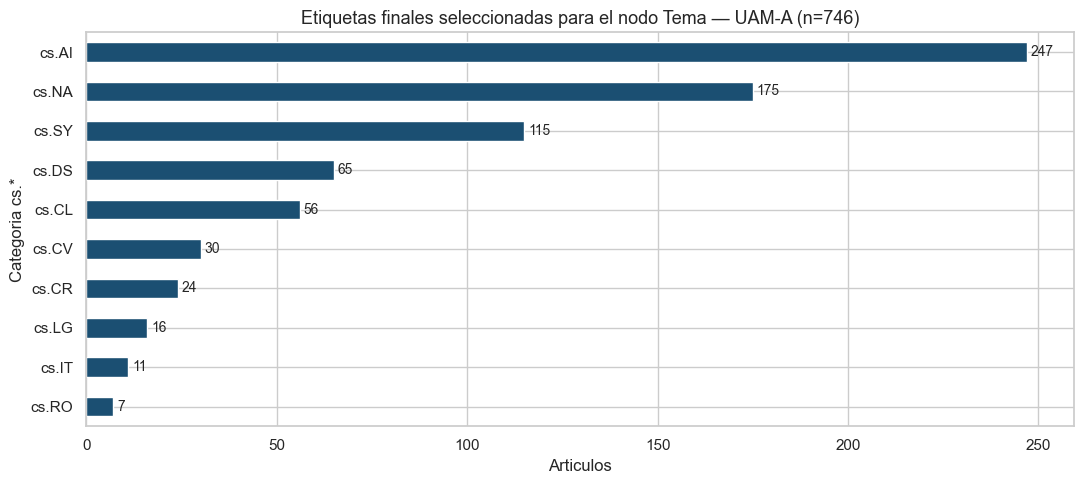

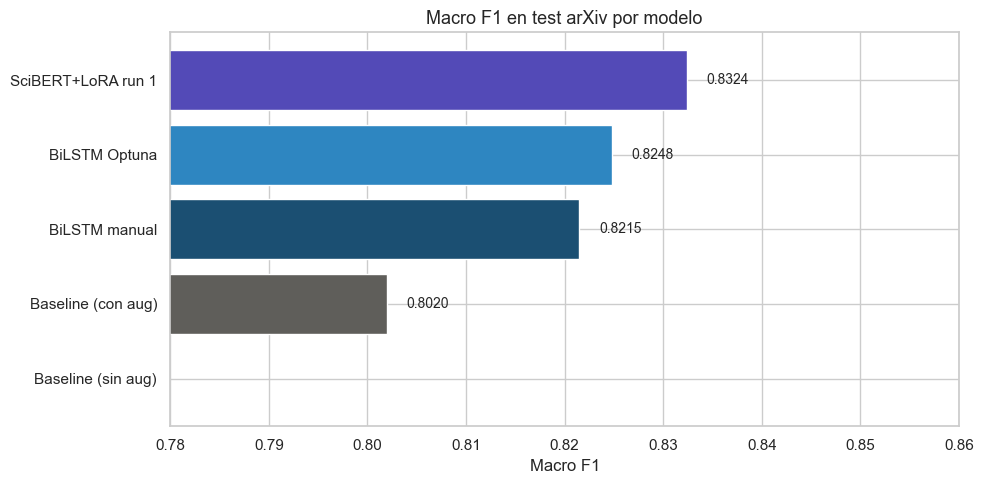

Columna year no disponible — grafica temporal omitida.


In [29]:
# Grafica 1: Distribucion de etiquetas finales seleccionadas
fig, ax = plt.subplots(figsize=(11, 5))
dist_final_ord = df_maestro['etiqueta_final'].value_counts().sort_values(ascending=True)
colores_barra  = ['#148F77' if df_maestro[df_maestro['etiqueta_final'] == cat]['confianza'].value_counts().index[0] == 'alta'
                  else '#1B4F72' for cat in dist_final_ord.index]
dist_final_ord.plot(kind='barh', ax=ax, color='#1B4F72', edgecolor='white')
for i, (cat, val) in enumerate(dist_final_ord.items()):
    ax.text(val + 1, i, str(val), va='center', fontsize=10)
ax.set_title('Etiquetas finales seleccionadas para el nodo Tema — UAM-A (n=746)', fontsize=13)
ax.set_xlabel('Articulos')
ax.set_ylabel('Categoria cs.*')
plt.tight_layout()
plt.savefig('etiquetas_finales_grafo.png', dpi=150)
plt.show()

# Grafica 2: F1 en arXiv por modelo (barras horizontales)
modelos_f1 = [
    ('Baseline (sin aug)',    0.000),  # reemplazar con valor real
    ('Baseline (con aug)',    0.8020),
    ('BiLSTM manual',         0.8215),
    ('BiLSTM Optuna',         0.8248),
    ('SciBERT+LoRA run 1',    0.8324),
]
nombres_f1 = [m[0] for m in modelos_f1]
valores_f1 = [m[1] for m in modelos_f1]
colores_f1 = ['#888780', '#5F5E5A', '#1B4F72', '#2E86C1', '#534AB7']

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(nombres_f1, valores_f1, color=colores_f1, edgecolor='white')
for barra, val in zip(barras, valores_f1):
    if val > 0:
        ax.text(val + 0.002, barra.get_y() + barra.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)
ax.set_xlim(0.78, 0.86)
ax.set_title('Macro F1 en test arXiv por modelo', fontsize=13)
ax.set_xlabel('Macro F1')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.savefig('comparativa_f1_arxiv.png', dpi=150)
plt.show()

# Grafica 3: Evolucion temporal si el dataset tiene columna de año
if 'year' in df_maestro.columns:
    df_temp = df_maestro.groupby(['year', 'etiqueta_final']).size().unstack(fill_value=0)
    top5 = df_maestro['etiqueta_final'].value_counts().head(5).index.tolist()
    df_temp = df_temp[top5]
    df_temp = df_temp[df_temp.index.between(2000, 2024)]

    fig, ax = plt.subplots(figsize=(13, 5))
    for cat in top5:
        ax.plot(df_temp.index, df_temp[cat], marker='o', markersize=4, label=cat)
    ax.set_title('Evolucion temporal de lineas de investigacion — UAM-A', fontsize=13)
    ax.set_xlabel('Año')
    ax.set_ylabel('Articulos')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('evolucion_temporal_uam.png', dpi=150)
    plt.show()
else:
    print('Columna year no disponible — grafica temporal omitida.')

## Celda 11 — Guardado de archivos de resultados finales

In [30]:
# Guardar DataFrame maestro con etiquetas finales y niveles de confianza
columnas_salida = [
    #'id', 'title', 
    'Resumen',
    'pred_bilstm', 'pred_scibert', 'pred_zeroshot',
    'etiqueta_final', 'confianza'
]
if 'retry_flag' in df_maestro.columns:
    columnas_salida.append('retry_flag')
if 'year' in df_maestro.columns:
    columnas_salida.insert(3, 'year')

df_salida = df_maestro[columnas_salida]
df_salida.to_parquet(OUTPUT_PATH, index=False)
print(f'Archivo de resultados final guardado: {OUTPUT_PATH}')
print(f'Shape: {df_salida.shape}')

# Guardar resumen JSON de la fase 7 para documentacion de tesis
resumen_fase7 = {
    'n_articulos_uam':        len(df_maestro),
    'concordancia_bilstm_scibert':   float(acuerdo_bs / n),
    'concordancia_bilstm_zeroshot':  float(acuerdo_bz / n),
    'concordancia_scibert_zeroshot': float(acuerdo_sz / n),
    'concordancia_tres_modelos':     float(acuerdo_all / n),
    'n_confianza_alta':   int((df_maestro['confianza'] == 'alta').sum()),
    'n_confianza_media':  int((df_maestro['confianza'] == 'media').sum()),
    'n_confianza_baja':   int((df_maestro['confianza'] == 'baja').sum()),
    'distribucion_etiqueta_final': df_maestro['etiqueta_final'].value_counts().to_dict(),
    'politica_decision': 'mayoria; empate: SciBERT > Zero-shot > BiLSTM',
    'ground_truth_disponible': False,
    'hallazgo_principal': 'BiLSTM nunca predice cs.LG; Zero-shot asigna 58 articulos a cs.LG sugiriendo sesgo lexical en modelos supervisados'
}

with open('fase7_resumen.json', 'w', encoding='utf-8') as f:
    json.dump(resumen_fase7, f, ensure_ascii=False, indent=2)
print('Resumen de Fase 7 guardado: fase7_resumen.json')

# Reporte final en pantalla
print('\n' + '=' * 60)
print('RESUMEN FINAL — FASE 7')
print('=' * 60)
print(f"Articulos UAM-A procesados       : {len(df_maestro):,}")
print(f"Concordancia tres modelos         : {acuerdo_all/n*100:.1f}%")
print(f"Confianza alta (grafo prioritario): {(df_maestro['confianza']=='alta').sum()} articulos")
print(f"Archivo final para el grafo       : {OUTPUT_PATH}")
print('=' * 60)

Archivo de resultados final guardado: uam_a_etiquetado_final.parquet
Shape: (746, 6)
Resumen de Fase 7 guardado: fase7_resumen.json

RESUMEN FINAL — FASE 7
Articulos UAM-A procesados       : 746
Concordancia tres modelos         : 4014.3%
Confianza alta (grafo prioritario): 663 articulos
Archivo final para el grafo       : uam_a_etiquetado_final.parquet
